In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml

germinal = pd.read_csv("/home/bri/pymol/EDA/static/germinal_outputs/scores_df_extended_with_chai.csv")
mcmahon = pd.read_csv("/home/bri/pymol/EDA/static/mcmahon_outputs/scores_df_extended_with_chai.csv")
snir = pd.read_csv("/home/bri/pymol/EDA/static/snir_outputs/scores_df_extended_with_chai.csv")
harvey =pd.read_csv("/home/bri/pymol/EDA/static/harvey_outputs/scores_df_extended_with_chai.csv")
YAML_PATH =  Path("/home/bri/pymol/EDA/static/metric_directions.yaml")
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/rankings")
OUTPUT_DIR.mkdir(exist_ok=True)


print(f"Germinal:\n{germinal['binder'].value_counts()}")
print(f"McMahon:\n{mcmahon['binder'].value_counts()}")
print(f"Snir:\n{snir['binder'].value_counts()}")
print(f"Harvey:\n{harvey['binder'].value_counts()}")


#snir.head()

Germinal:
binder
0    456
1     24
Name: count, dtype: int64
McMahon:
binder
0    26
1    19
Name: count, dtype: int64
Snir:
binder
0    32
1     3
Name: count, dtype: int64
Harvey:
binder
1.0    30
0.0     7
Name: count, dtype: int64


In [3]:
import pandas as pd

# 3 specific types
types = {
    (1, "original"): 24,       # Positive
    (0, "original"): 13,       # Hard Negative
    (0, "target_shuffle"): 13  # Easy Negative
}

# other ds
other_combined = pd.concat([mcmahon, snir, harvey], axis=0)

combined_iterations = []

for i in range(1): # 6 iterations
    parts = []
    
    # Nested unpacking: (binder, type) comes from the key, n from the value
    for (binder, type), n in types.items():
        
        # Apply both filters to get the specific pool
        subset = germinal[(germinal['binder'] == binder) & 
                          (germinal['type'] == type)]
        
        # Draw n samples from this specific pool
        parts.append(subset.sample(n=n, random_state=i))
    
    # Combine the 3 parts (10+20+20 = 50 rows total per iteration)
    iteration_df = pd.concat(parts).sample(frac=1, random_state=i)
    iteration_df["iteration"] = i

    
    # Add the iteration label to snir/mcmahon
    base_with_label = other_combined.copy()
    base_with_label["iteration"] = i
    
    # combine
    combined_iteration = pd.concat([base_with_label, iteration_df], axis=0)
    
    combined_iterations.append(combined_iteration)

# single large df where each iteration (0-9) 
df = pd.concat(combined_iterations).reset_index(drop=True)
df.to_csv(OUTPUT_DIR / "scores_df_merged_final.csv", index=False)

In [4]:
print(f"Subsampled Germinal:\n{df['source'].value_counts()}")
print(f"Subsampled Germinal:\n{df['binder'].value_counts()}")
print(f"Subsampled Germinal Types:\n{df['type'].value_counts()}")
print(f"Subsampled Germinal:\n{df['iteration'].value_counts()}")

Subsampled Germinal:
source
germinal    50
mcmahon     45
harvey      37
snir_ab     35
Name: count, dtype: int64
Subsampled Germinal:
binder
0.0    91
1.0    76
Name: count, dtype: int64
Subsampled Germinal Types:
type
original          104
alanine_scan       32
target_shuffle     31
Name: count, dtype: int64
Subsampled Germinal:
iteration
0    167
Name: count, dtype: int64


In [5]:
cols_to_drop = (['af3_rank', 'af3_ranking_score', 'af3_rank0_masif', 'cf_rank', 'cf_rank0_masif'])

scores_df = df.drop(columns=cols_to_drop)

# ── FIX 1: define binder_type HERE so it exists before scaling ──
def categorize_row(row):
    if row['binder'] == 1:
        return 'Binder'
    elif row['type'] == 'original':  # binder == 0
        return 'Non-Binder'
    else:  # binder == 0 and type == target_shuffle
        return 'Target Shuffle'

scores_df['binder_type'] = scores_df.apply(categorize_row, axis=1)

colors_map = {
    'Binder':         '#2ecc71',
    'Non-Binder':     '#67e7dd',
    'Target Shuffle': '#273397',
    'germinal':       '#2ecc71',
    'mcmahon':        '#d6a439',
    'snir_ab':        '#1f3397',
    'harvey':        "#971f6f",
}

# DataFrame 1 – preprocessed, original scale
scores_df.head()


,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm,iteration,binder_type
0,mcmahon,original,1.0,0.0,NaN,Nb.b201_HSA_404-609,6.376025,88.098892,14.46,1.51,...,0.9208,0.4745,0.886037,0.897680,0.171786,0.758631,NaN,NaN,0,Binder
1,mcmahon,original,1.0,0.0,NaN,Nb.b201_HSA_404-601,6.893648,87.943351,19.06,1.99,...,0.0374,0.0189,0.878948,0.880200,0.147295,0.598787,NaN,NaN,0,Binder
2,mcmahon,original,1.0,0.0,NaN,Nb.b201_HSA_25-609,13.189712,84.282269,154.23,10.06,...,0.7323,0.5462,0.877172,0.878092,0.255400,0.682429,NaN,NaN,0,Binder
3,mcmahon,original,1.0,0.000002,NaN,Nb.AQ100_Adiponectin,12.931578,81.319338,205.51,11.33,...,0.0783,0.2570,0.882637,0.875993,0.159133,0.256621,NaN,NaN,0,Binder
4,mcmahon,original,0.0,NaN,NaN,Nb.AQ101_Adiponectin,13.803496,80.758365,46.76,3.01,...,0.0450,0.1986,0.881152,0.878127,0.171685,0.326672,NaN,NaN,0,Non-Binder


### data transformation

In [6]:
# single authoritative definition of numeric_cols
# meta_cols is defined first so numeric_cols is derived from it,
# not the other way round. KD[M] / EC50[M] stay excluded.
meta_cols    = ['sample', 'binder', 'source', 'type', 'iteration', 'binder_type']
exclude_cols = ['KD[M]', 'EC50[M]']

numeric_cols = [
    c for c in scores_df.columns
    if c not in meta_cols and c not in exclude_cols
]

print(f"{len(numeric_cols)} numeric metric columns selected")
numeric_cols


82 numeric metric columns selected


['af3_pae',
 'af3_plddt',
 'af3_interface_dG',
 'af3_interface_dG_SASA_ratio',
 'af3_ipae',
 'af3_iplddt',
 'af3_ipsae',
 'af3_pdockq',
 'af3_pdockq2',
 'af3_lis',
 'af3_iptm',
 'af3_ptm',
 'af3_pyros_binder_score',
 'cf_af3_rmsd',
 'cf_pae',
 'cf_plddt',
 'cf_interface_dG',
 'cf_interface_dG_SASA_ratio',
 'cf_ipae',
 'cf_iplddt',
 'cf_ipsae',
 'cf_pdockq',
 'cf_pdockq2',
 'cf_lis',
 'cf_iptm',
 'cf_ptm',
 'cf_pyros_binder_score',
 'pred_ilddt',
 'pred_lddt',
 'esmfold_ipae',
 'esmfold_iplddt',
 'esmfold_plddt',
 'esmfold_pae',
 'esmfold_ptm',
 'chai_unconstrained_score',
 'chai_constrained_score',
 'chai_unconstrained_aggregate_score',
 'chai_unconstrained_ptm',
 'chai_unconstrained_iptm',
 'chai_unconstrained_interface_iptm',
 'chai_unconstrained_ipsae',
 'chai_unconstrained_pdockq',
 'chai_unconstrained_pdockq2',
 'chai_unconstrained_lis',
 'chai_constrained_aggregate_score',
 'chai_constrained_ptm',
 'chai_constrained_iptm',
 'chai_constrained_interface_iptm',
 'chai_constrained_ip

In [7]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()   # try standard and quntile too

# DataFrame 2 – scaled, comparable magnitude
scores_df_scaled = scores_df.copy()
scores_df_scaled[numeric_cols] = scaler.fit_transform(scores_df[numeric_cols])

scores_df_scaled.head()


,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm,iteration,binder_type
0,mcmahon,original,1.0,0.0,NaN,Nb.b201_HSA_404-609,-0.462989,0.449174,-0.429650,-0.534479,...,0.879689,-0.231652,0.259985,0.419992,-0.131492,0.766984,NaN,NaN,0,Binder
1,mcmahon,original,1.0,0.0,NaN,Nb.b201_HSA_404-601,-0.398599,0.436547,-0.411513,-0.488666,...,-0.798025,-1.891095,0.194574,0.212561,-0.209297,0.462148,NaN,NaN,0,Binder
2,mcmahon,original,1.0,0.0,NaN,Nb.b201_HSA_25-609,0.384609,0.139332,0.121439,0.281556,...,0.521698,0.029503,0.178187,0.187551,0.134141,0.621661,NaN,NaN,0,Binder
3,mcmahon,original,1.0,0.000002,NaN,Nb.AQ100_Adiponectin,0.352498,-0.101204,0.323627,0.402768,...,-0.720349,-1.023857,0.228616,0.162641,-0.171690,-0.190393,NaN,NaN,0,Binder
4,mcmahon,original,0.0,NaN,NaN,Nb.AQ101_Adiponectin,0.460961,-0.146745,-0.302297,-0.391315,...,-0.783591,-1.236569,0.214907,0.187963,-0.131813,-0.056798,NaN,NaN,0,Non-Binder


In [8]:
# Load metric directionality from YAML
# +1 → higher is better   -1 → lower is better

if Path(YAML_PATH).exists():
    with open(YAML_PATH, 'r') as f:
        yaml_data = yaml.safe_load(f)
    raw_directions = {k: v['direction'] for k, v in yaml_data['metrics'].items()}
    # sort longest-key-first so 'iptm' is checked before 'ptm'
    metric_directions = dict(sorted(raw_directions.items(), key=lambda x: len(x[0]), reverse=True))
    print(f"Loaded {len(metric_directions)} metric directions from YAML.")
else:
    print(f"WARNING: YAML not found at {YAML_PATH}. Using default direction (+1).")
    metric_directions = {}

def get_direction(col_name):
    """Return +1 / -1 for a metric column.
    
    ── FIX 4: use suffix match (col ends with '_<base>') instead of
    bare substring so 'ptm' cannot accidentally match 'iptm'.
    """
    for base_metric, direction in metric_directions.items():
        if col_name == base_metric or col_name.endswith(f'_{base_metric}'):
            return direction
    return 1  # default: higher is better

# DataFrame 3 – direction-aligned scaled values
scores_df_aligned = scores_df_scaled.copy()
for col in numeric_cols:
    scores_df_aligned[col] = scores_df_aligned[col] * get_direction(col)

print("DataFrame 3 (direction-aligned, scaled) shape:", scores_df_aligned.shape)
scores_df_aligned.head()


Loaded 88 metric directions from YAML.
DataFrame 3 (direction-aligned, scaled) shape: (167, 90)


,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm,iteration,binder_type
0,mcmahon,original,1.0,0.0,NaN,Nb.b201_HSA_404-609,0.462989,0.449174,0.429650,0.534479,...,0.879689,-0.231652,0.259985,0.419992,-0.131492,0.766984,NaN,NaN,0,Binder
1,mcmahon,original,1.0,0.0,NaN,Nb.b201_HSA_404-601,0.398599,0.436547,0.411513,0.488666,...,-0.798025,-1.891095,0.194574,0.212561,-0.209297,0.462148,NaN,NaN,0,Binder
2,mcmahon,original,1.0,0.0,NaN,Nb.b201_HSA_25-609,-0.384609,0.139332,-0.121439,-0.281556,...,0.521698,0.029503,0.178187,0.187551,0.134141,0.621661,NaN,NaN,0,Binder
3,mcmahon,original,1.0,0.000002,NaN,Nb.AQ100_Adiponectin,-0.352498,-0.101204,-0.323627,-0.402768,...,-0.720349,-1.023857,0.228616,0.162641,-0.171690,-0.190393,NaN,NaN,0,Binder
4,mcmahon,original,0.0,NaN,NaN,Nb.AQ101_Adiponectin,-0.460961,-0.146745,0.302297,0.391315,...,-0.783591,-1.236569,0.214907,0.187963,-0.131813,-0.056798,NaN,NaN,0,Non-Binder


In [14]:
# parse helper (unchanged)
def parse_metric(metric):
    parts = metric.split('_')
    if metric.startswith('chai_') or metric.startswith('boltz_'):
        model = '_'.join(parts[:2])
        metric_name = '_'.join(parts[2:])
    else:
        model = parts[0]
        metric_name = '_'.join(parts[1:])
    return model, metric_name

# melt scores_df_scaled
long_scores_df = pd.melt(
    scores_df,
    id_vars=['sample', 'binder', 'binder_type', 'source', 'type'],
    value_vars=numeric_cols,
    var_name='metric',
    value_name='value'
)

long_scores_df[['model', 'metric_family']] = (
    long_scores_df['metric']
    .apply(parse_metric)
    .apply(pd.Series)
)

long_scores_df.tail()

long_scores_df.to_csv(OUTPUT_DIR / "long_scores_df.csv", index=False)


In [15]:
# metric groupings – used for plotting
models = ['af3', 'cf', 'esmfold', 'chai_constrained', 'chai_unconstrained', 'boltz_free', 'boltz_template']
model_groups = {model: [c for c in numeric_cols if c.startswith(model)] for model in models}

metric_families = {
    'plddt':   ['af3_plddt', 'cf_plddt', 'esmfold_plddt', 'boltz_free_plddt', 'boltz_template_plddt'],
    'ptm':     ['af3_ptm', 'cf_ptm', 'esmfold_ptm', 'chai_unconstrained_ptm', 'chai_constrained_ptm',
                'boltz_free_ptm', 'boltz_template_ptm'],
    'iptm':    ['af3_iptm', 'cf_iptm', 'chai_unconstrained_iptm', 'chai_constrained_iptm',
                'boltz_free_iptm', 'boltz_template_iptm'],
    'pdockq2': ['af3_pdockq2', 'cf_pdockq2', 'chai_unconstrained_pdockq2', 'chai_constrained_pdockq2',
                'boltz_free_pdockq2', 'boltz_template_pdockq2'],
}


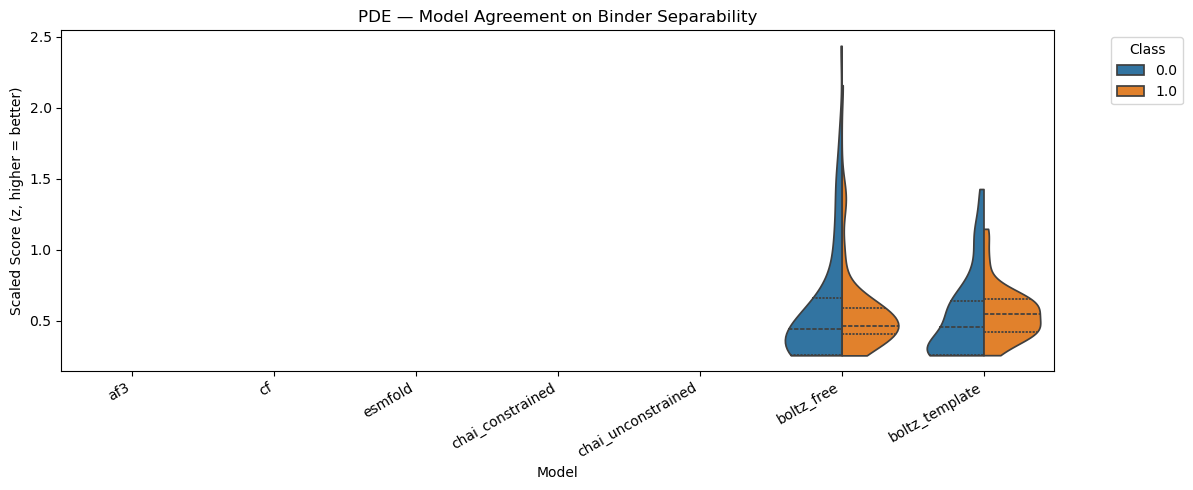

In [28]:
long_scores_df["binder_binary"] = long_scores_df["binder_type"].replace({
    "True Binder": "Binder",
    "Real Negative": "Non-Binder",
    "Hard Negative (Shuffle)": "Non-Binder"
})

import seaborn as sns
import matplotlib.pyplot as plt

family = "pde"
df_f = long_scores_df[long_scores_df["metric_family"] == family].copy()

model_order = [
    "af3",
    "cf",
    "esmfold",
    "chai_constrained",
    "chai_unconstrained",
    "boltz_free",
    "boltz_template"
]

plt.figure(figsize=(12, 5))

sns.violinplot(
    data=df_f,
    x="model",
    y="value",
    hue="binder",
    order=model_order,
    split=True,                 # <-- key feature
    inner="quartile",
    cut=0,
    density_norm="width"
)

plt.title(f"{family.upper()} — Model Agreement on Binder Separability")
plt.xlabel("Model")
plt.ylabel("Scaled Score (z, higher = better)")
plt.xticks(rotation=30, ha="right")

plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{family}_model_agreement.png", dpi=200)
plt.show()

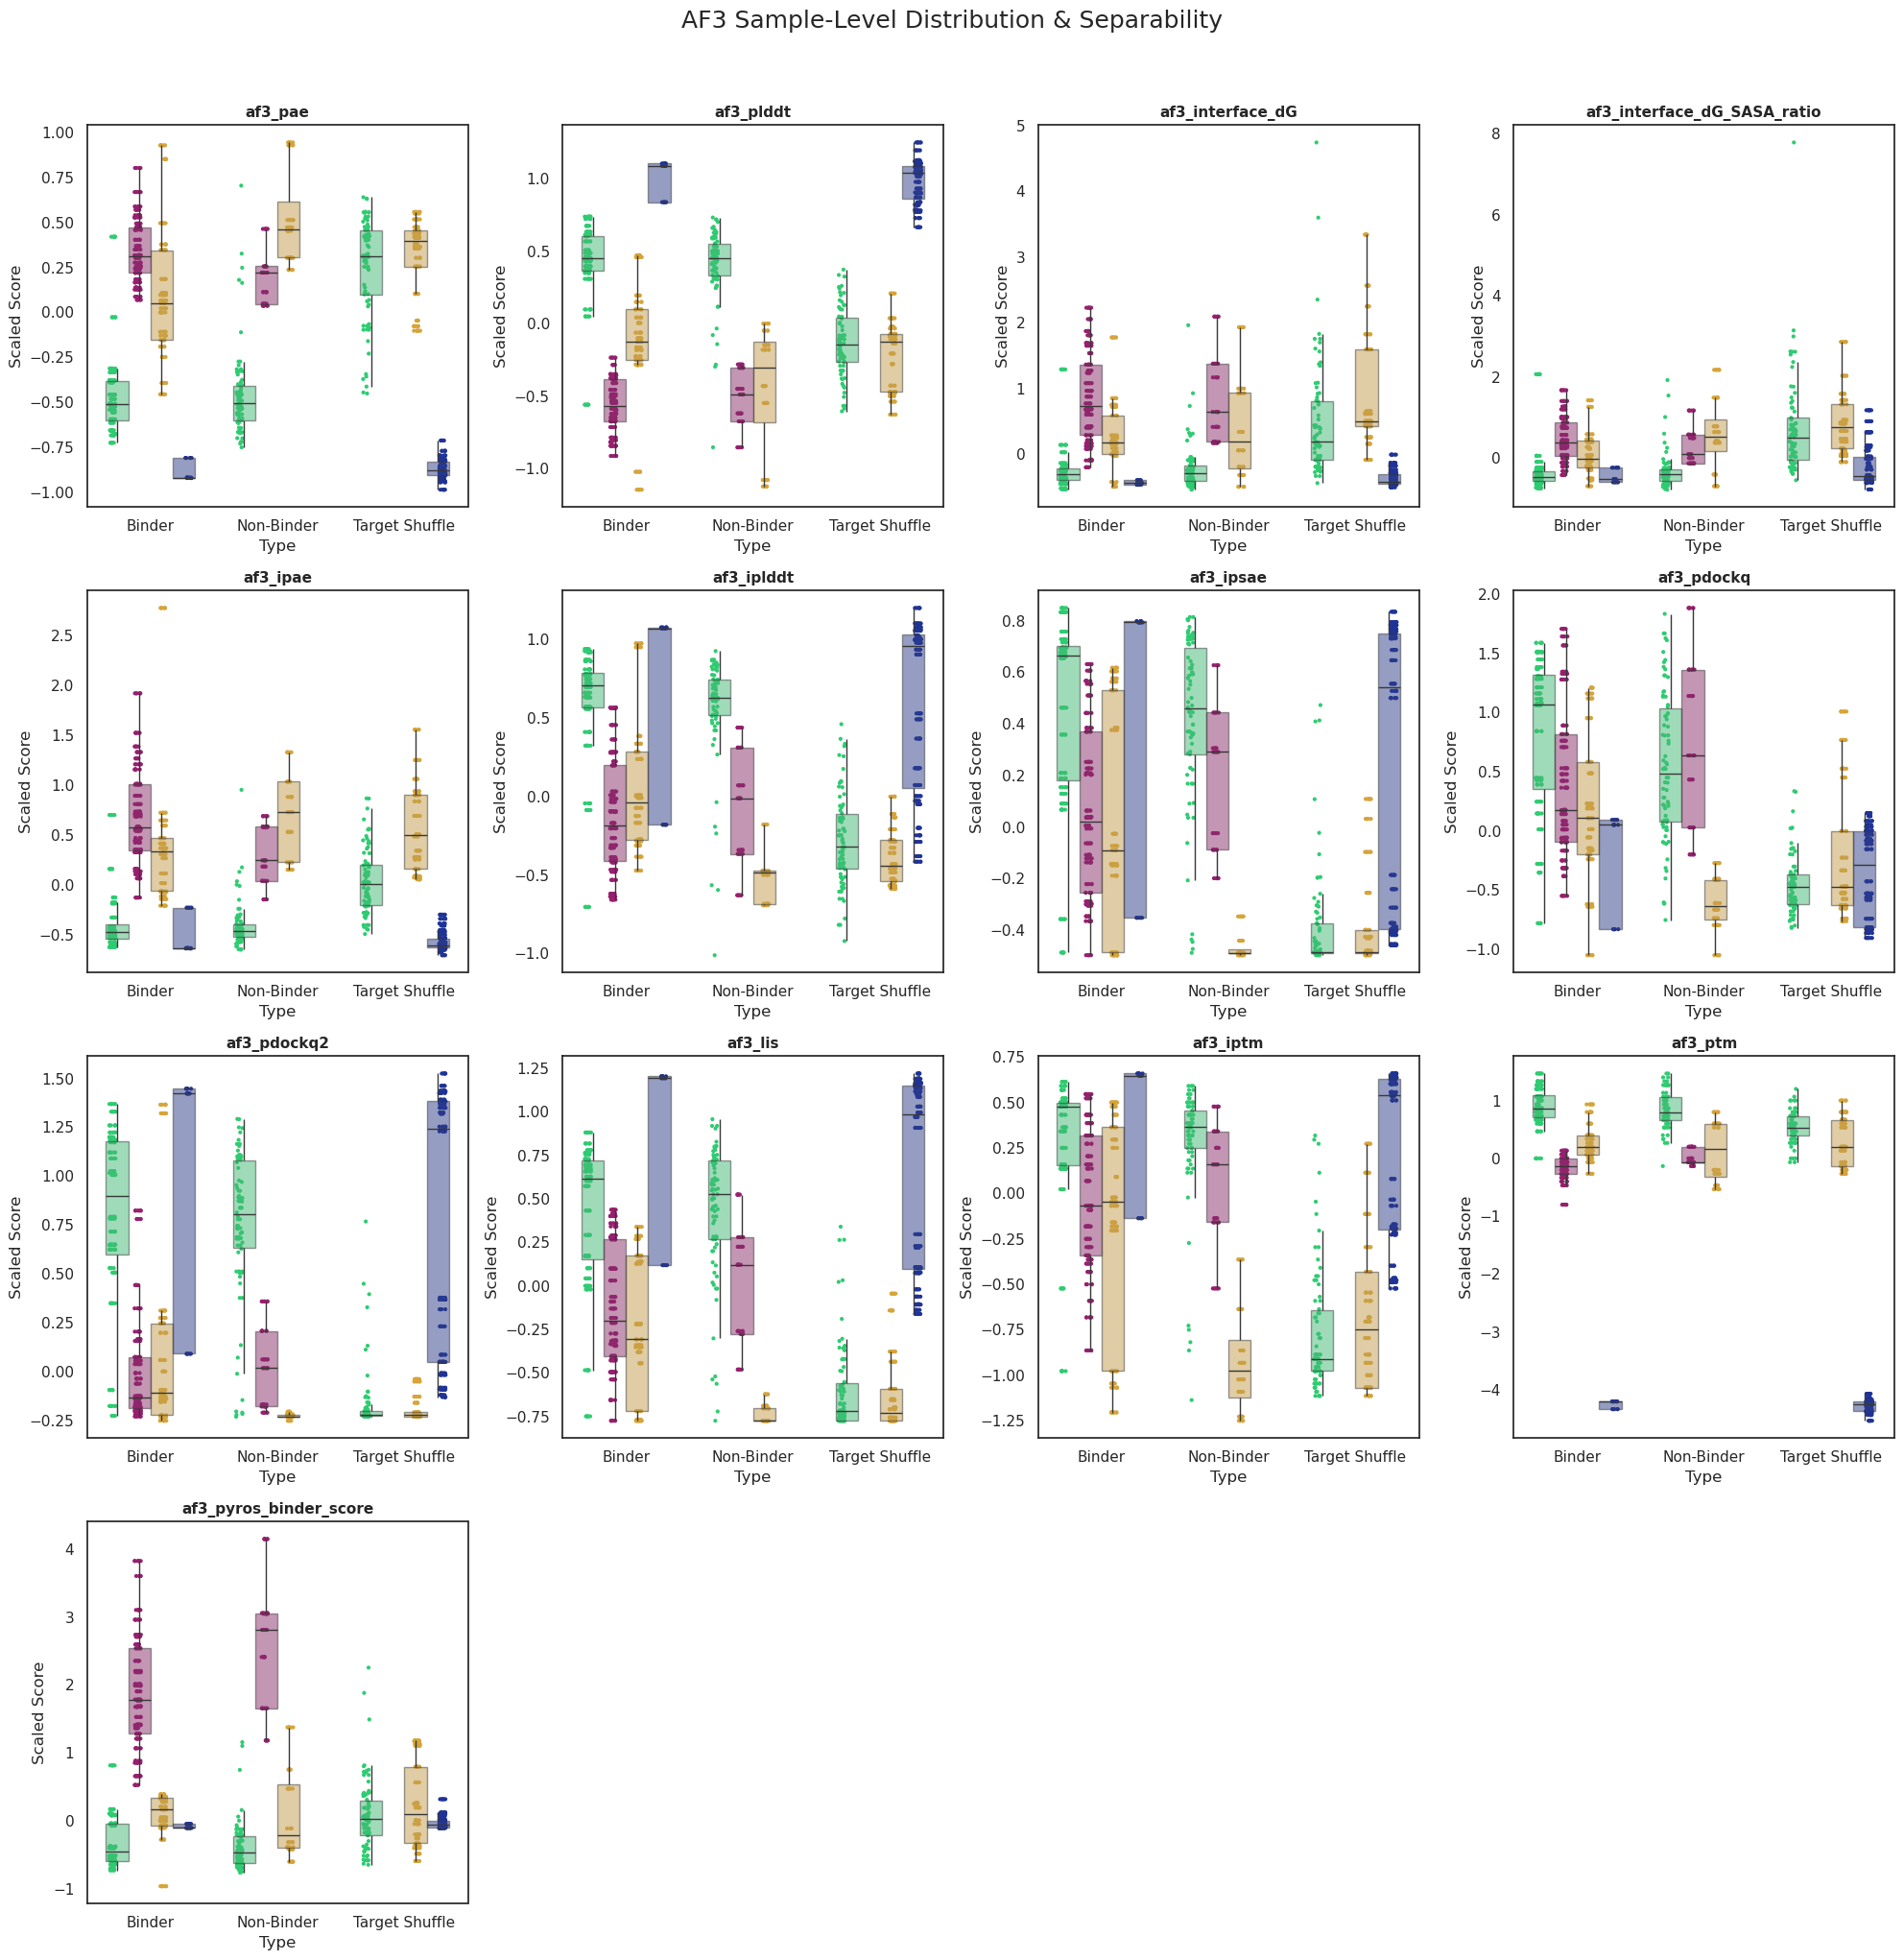

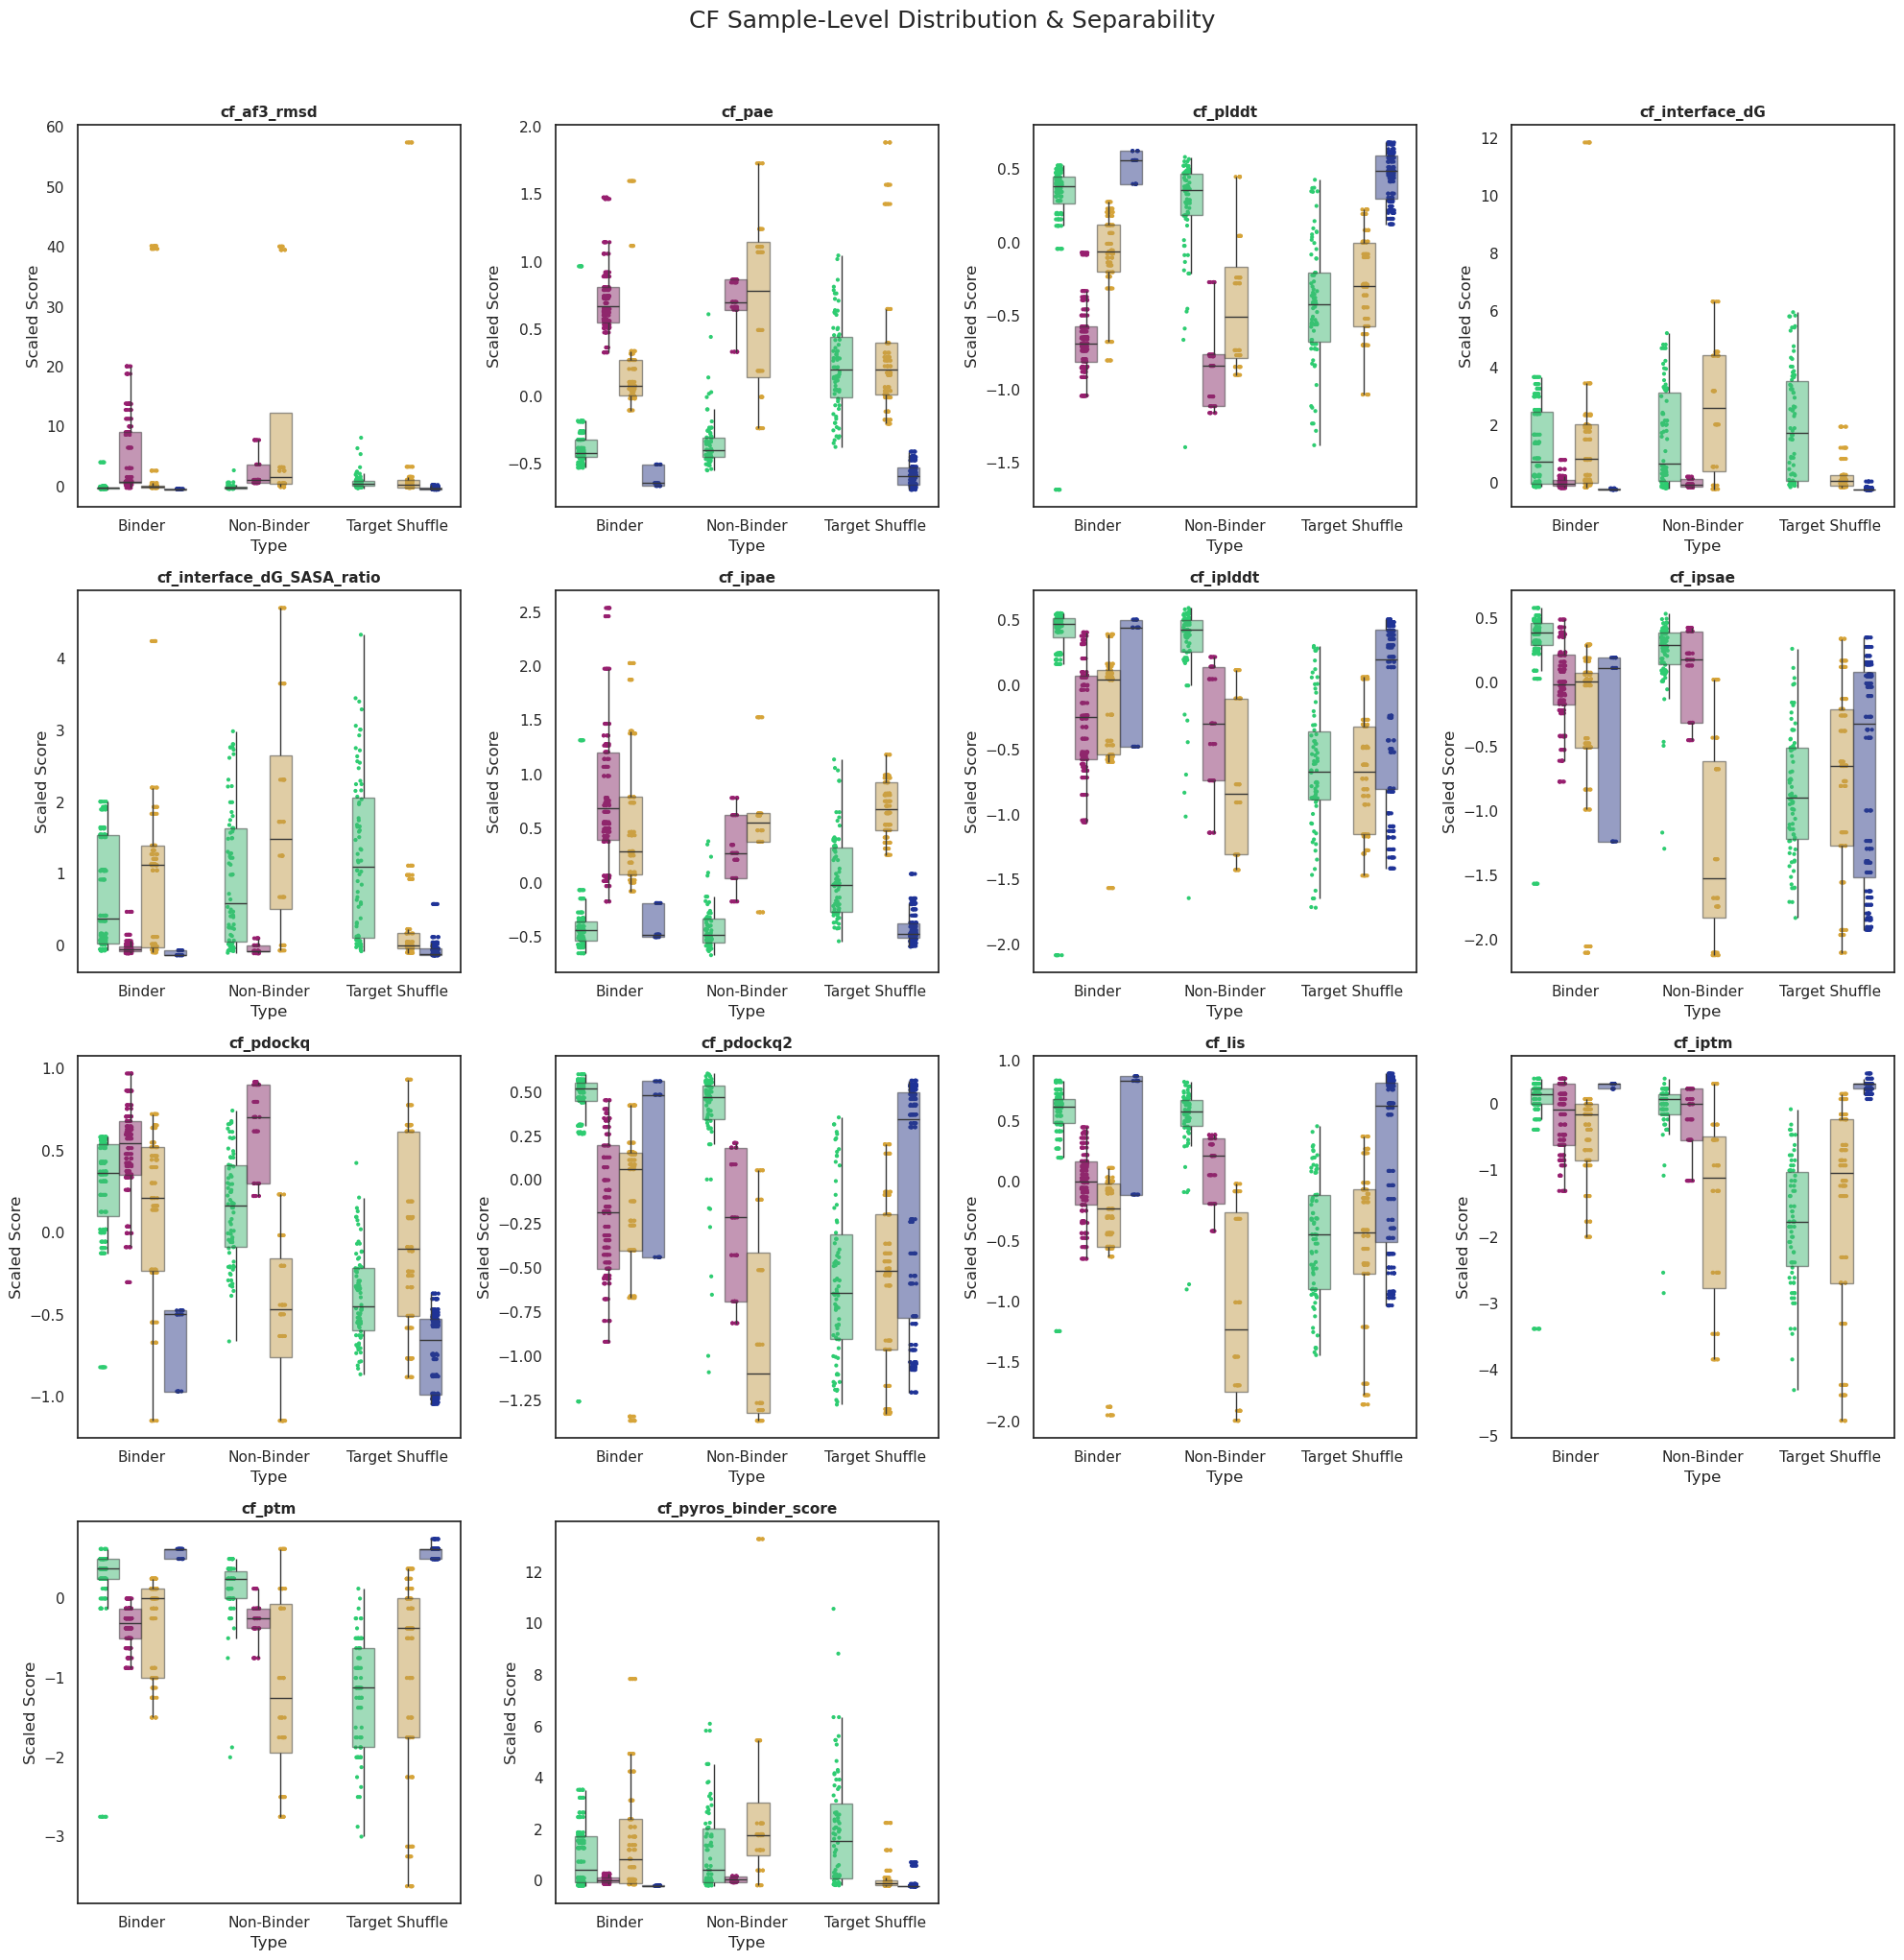

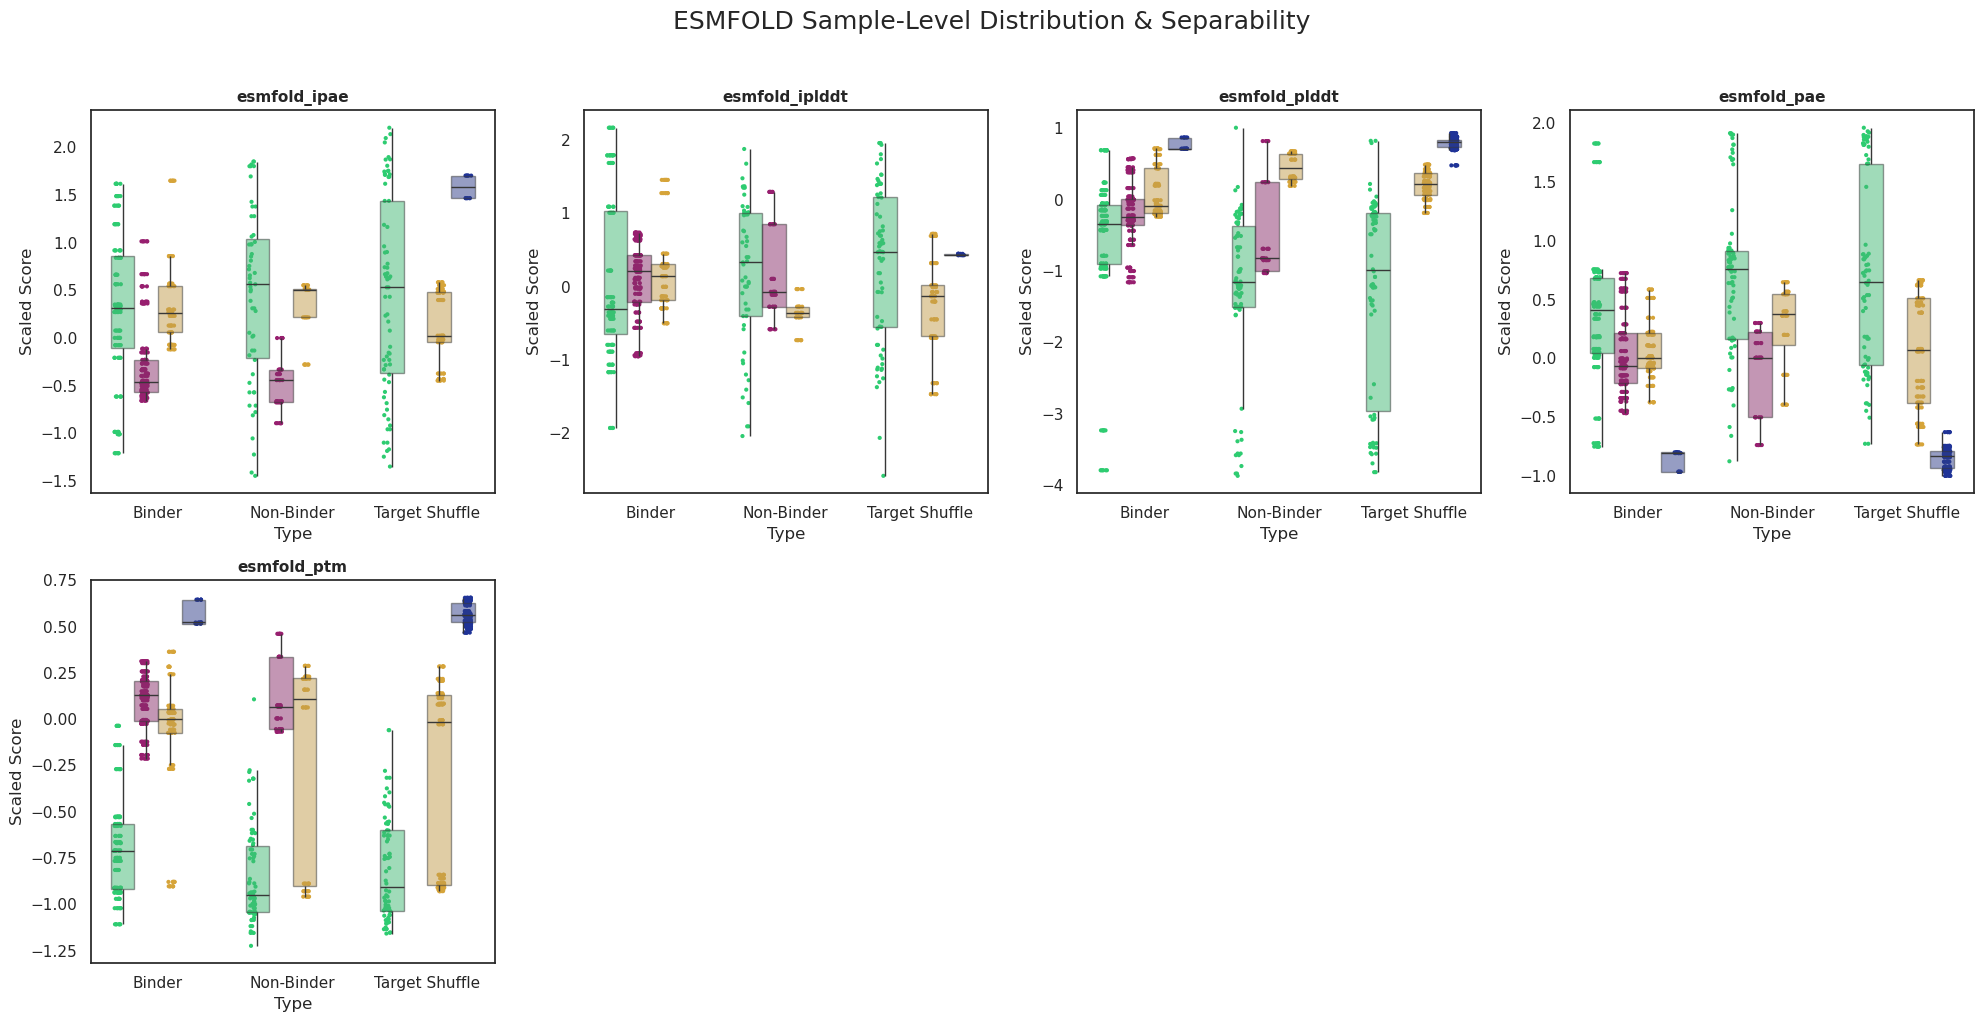

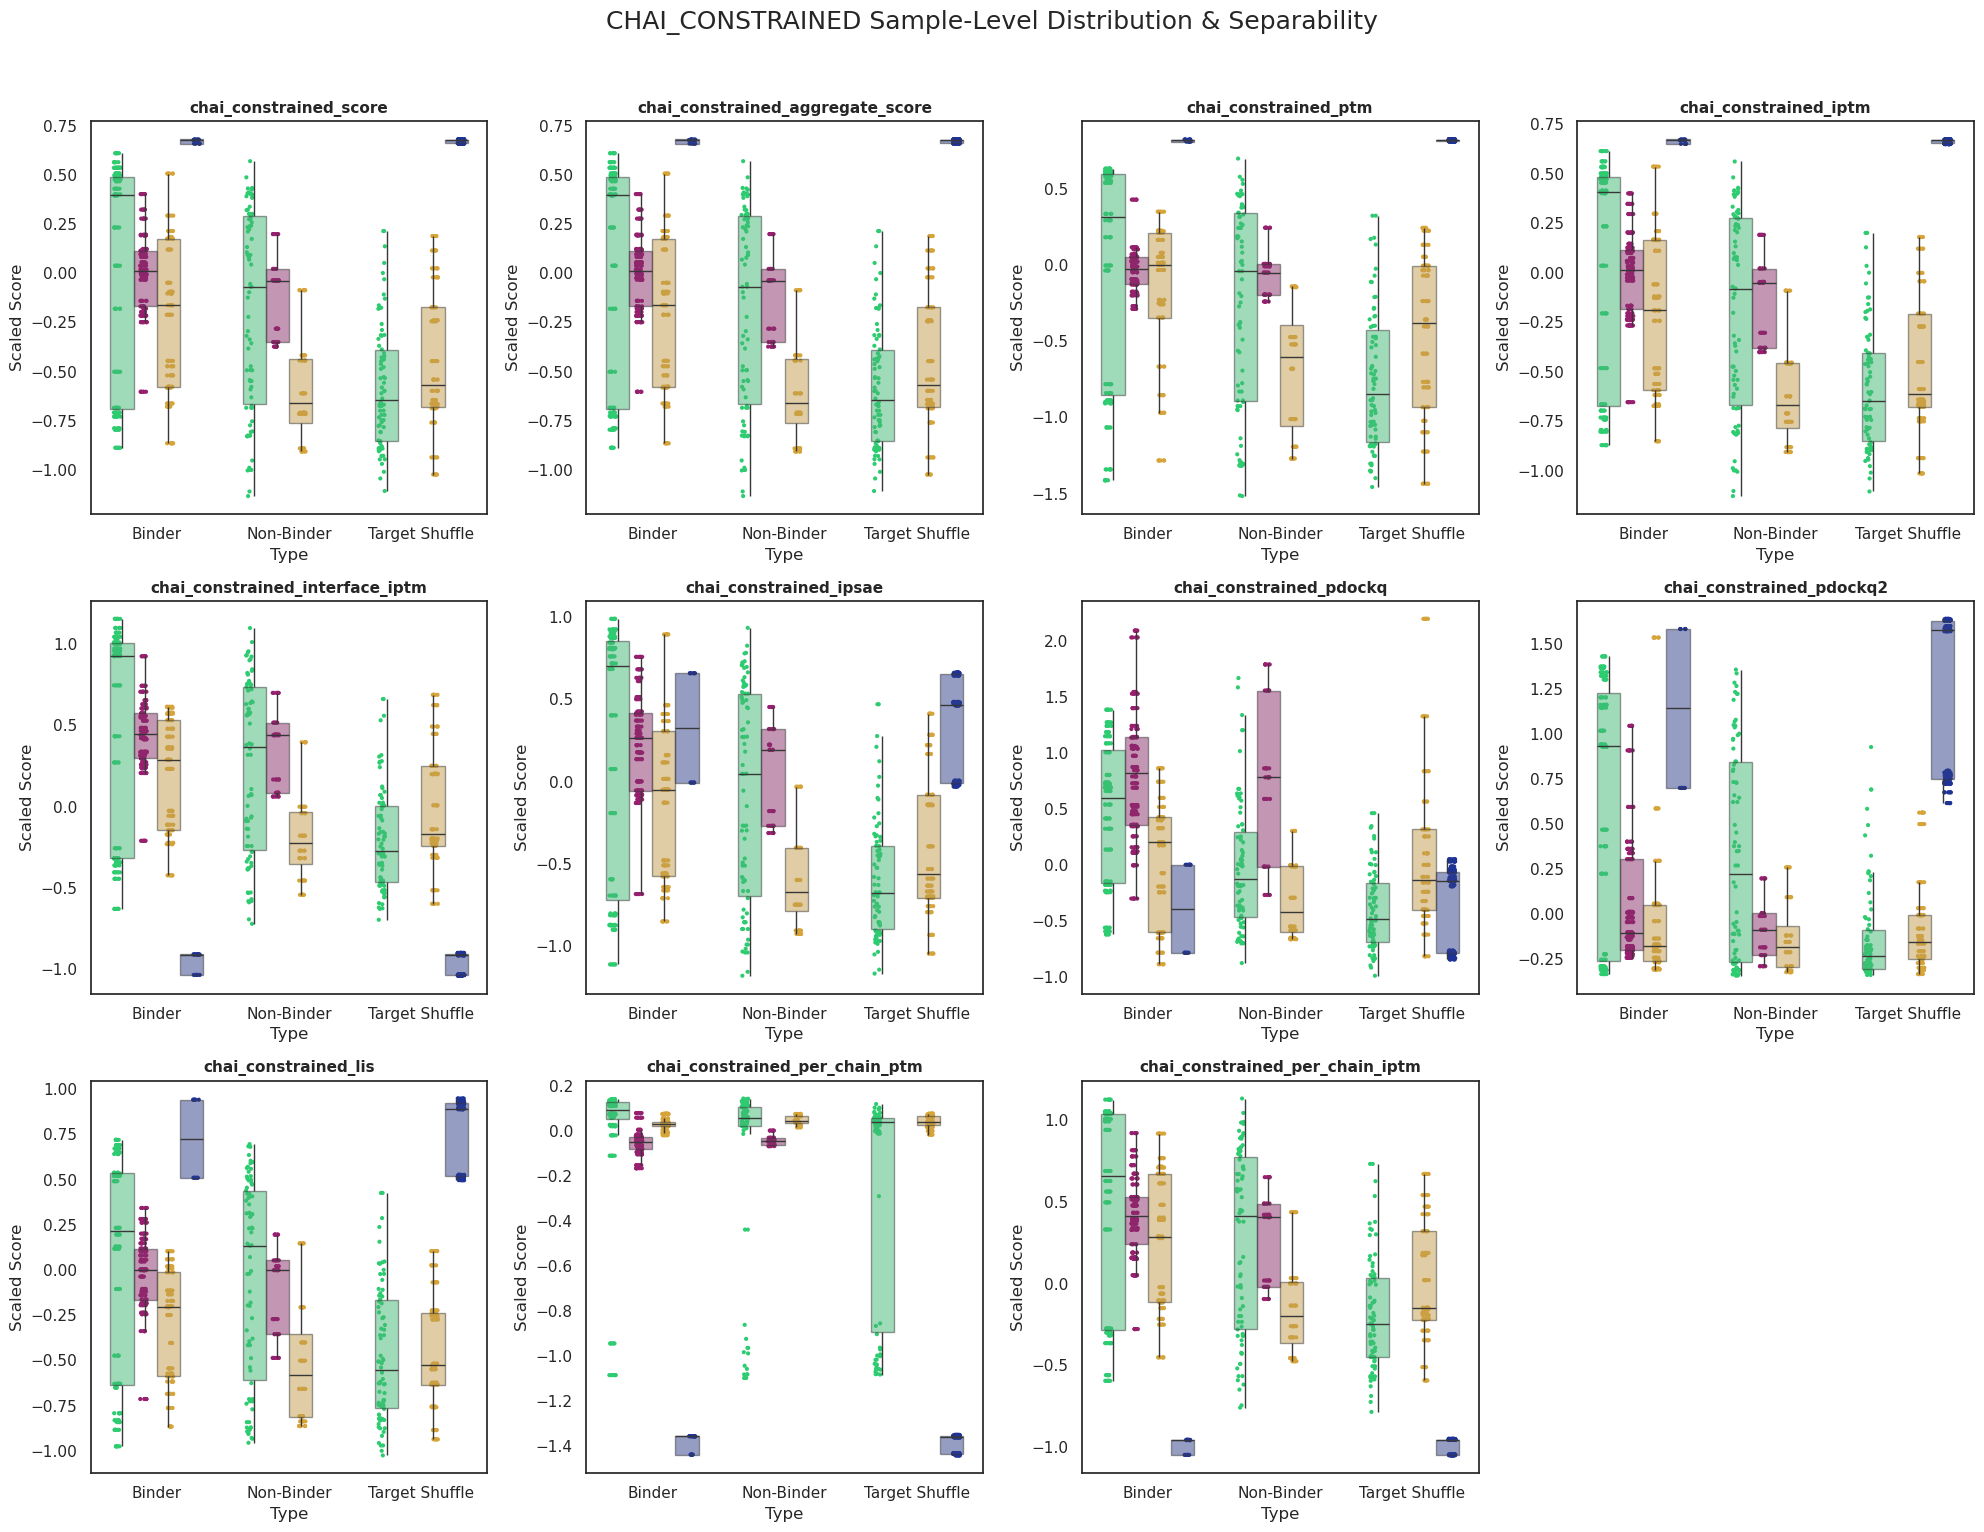

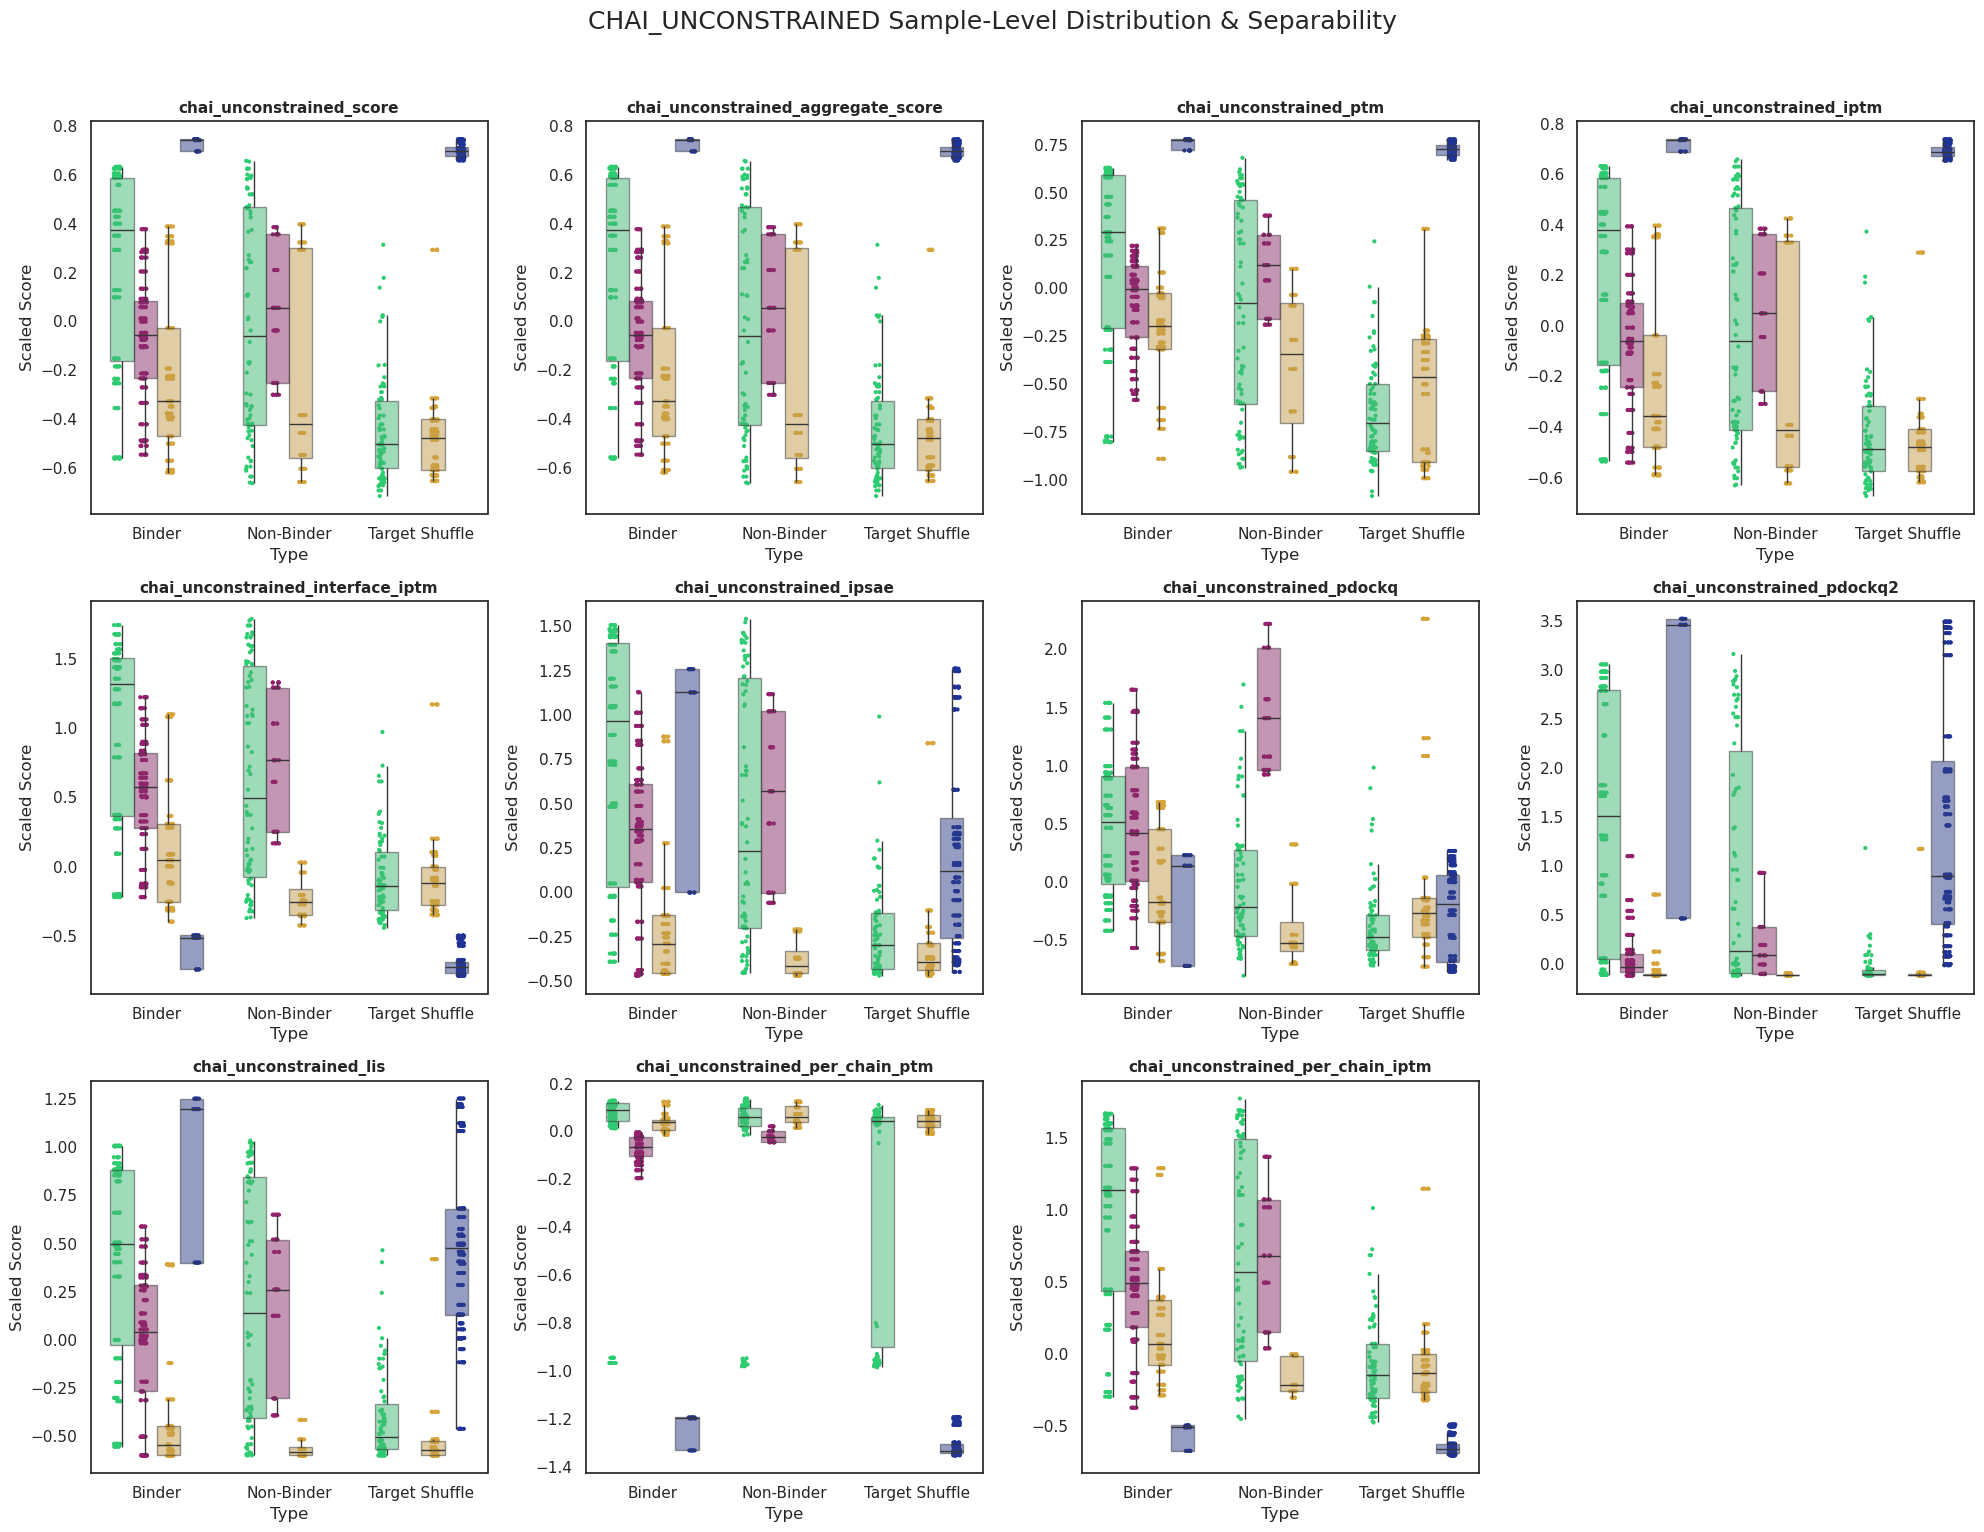

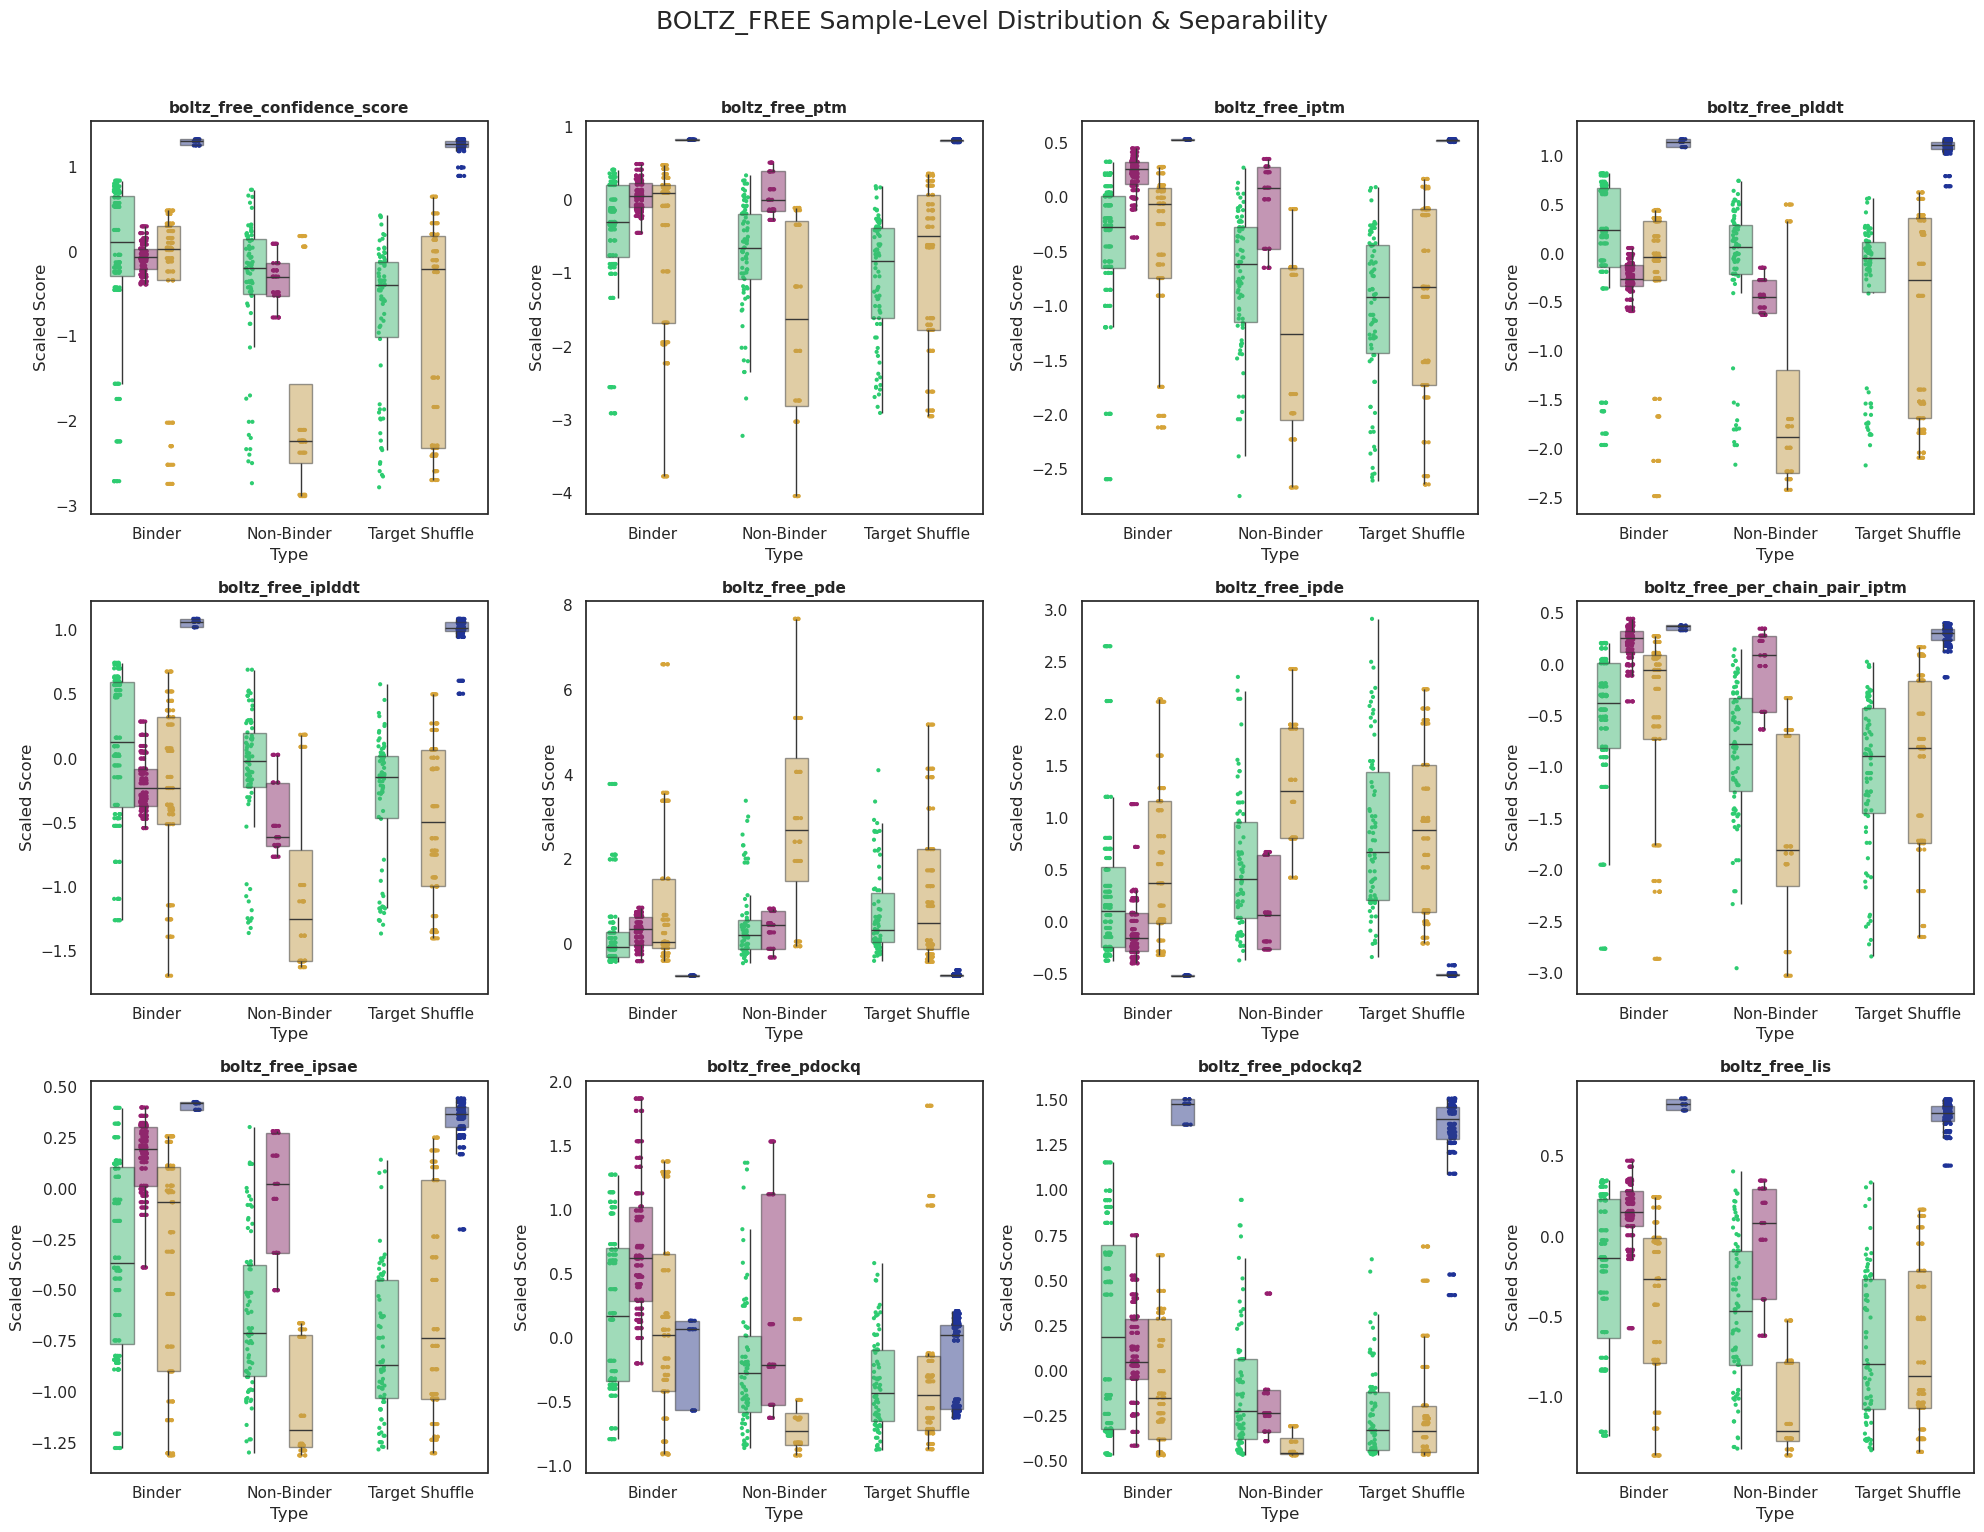

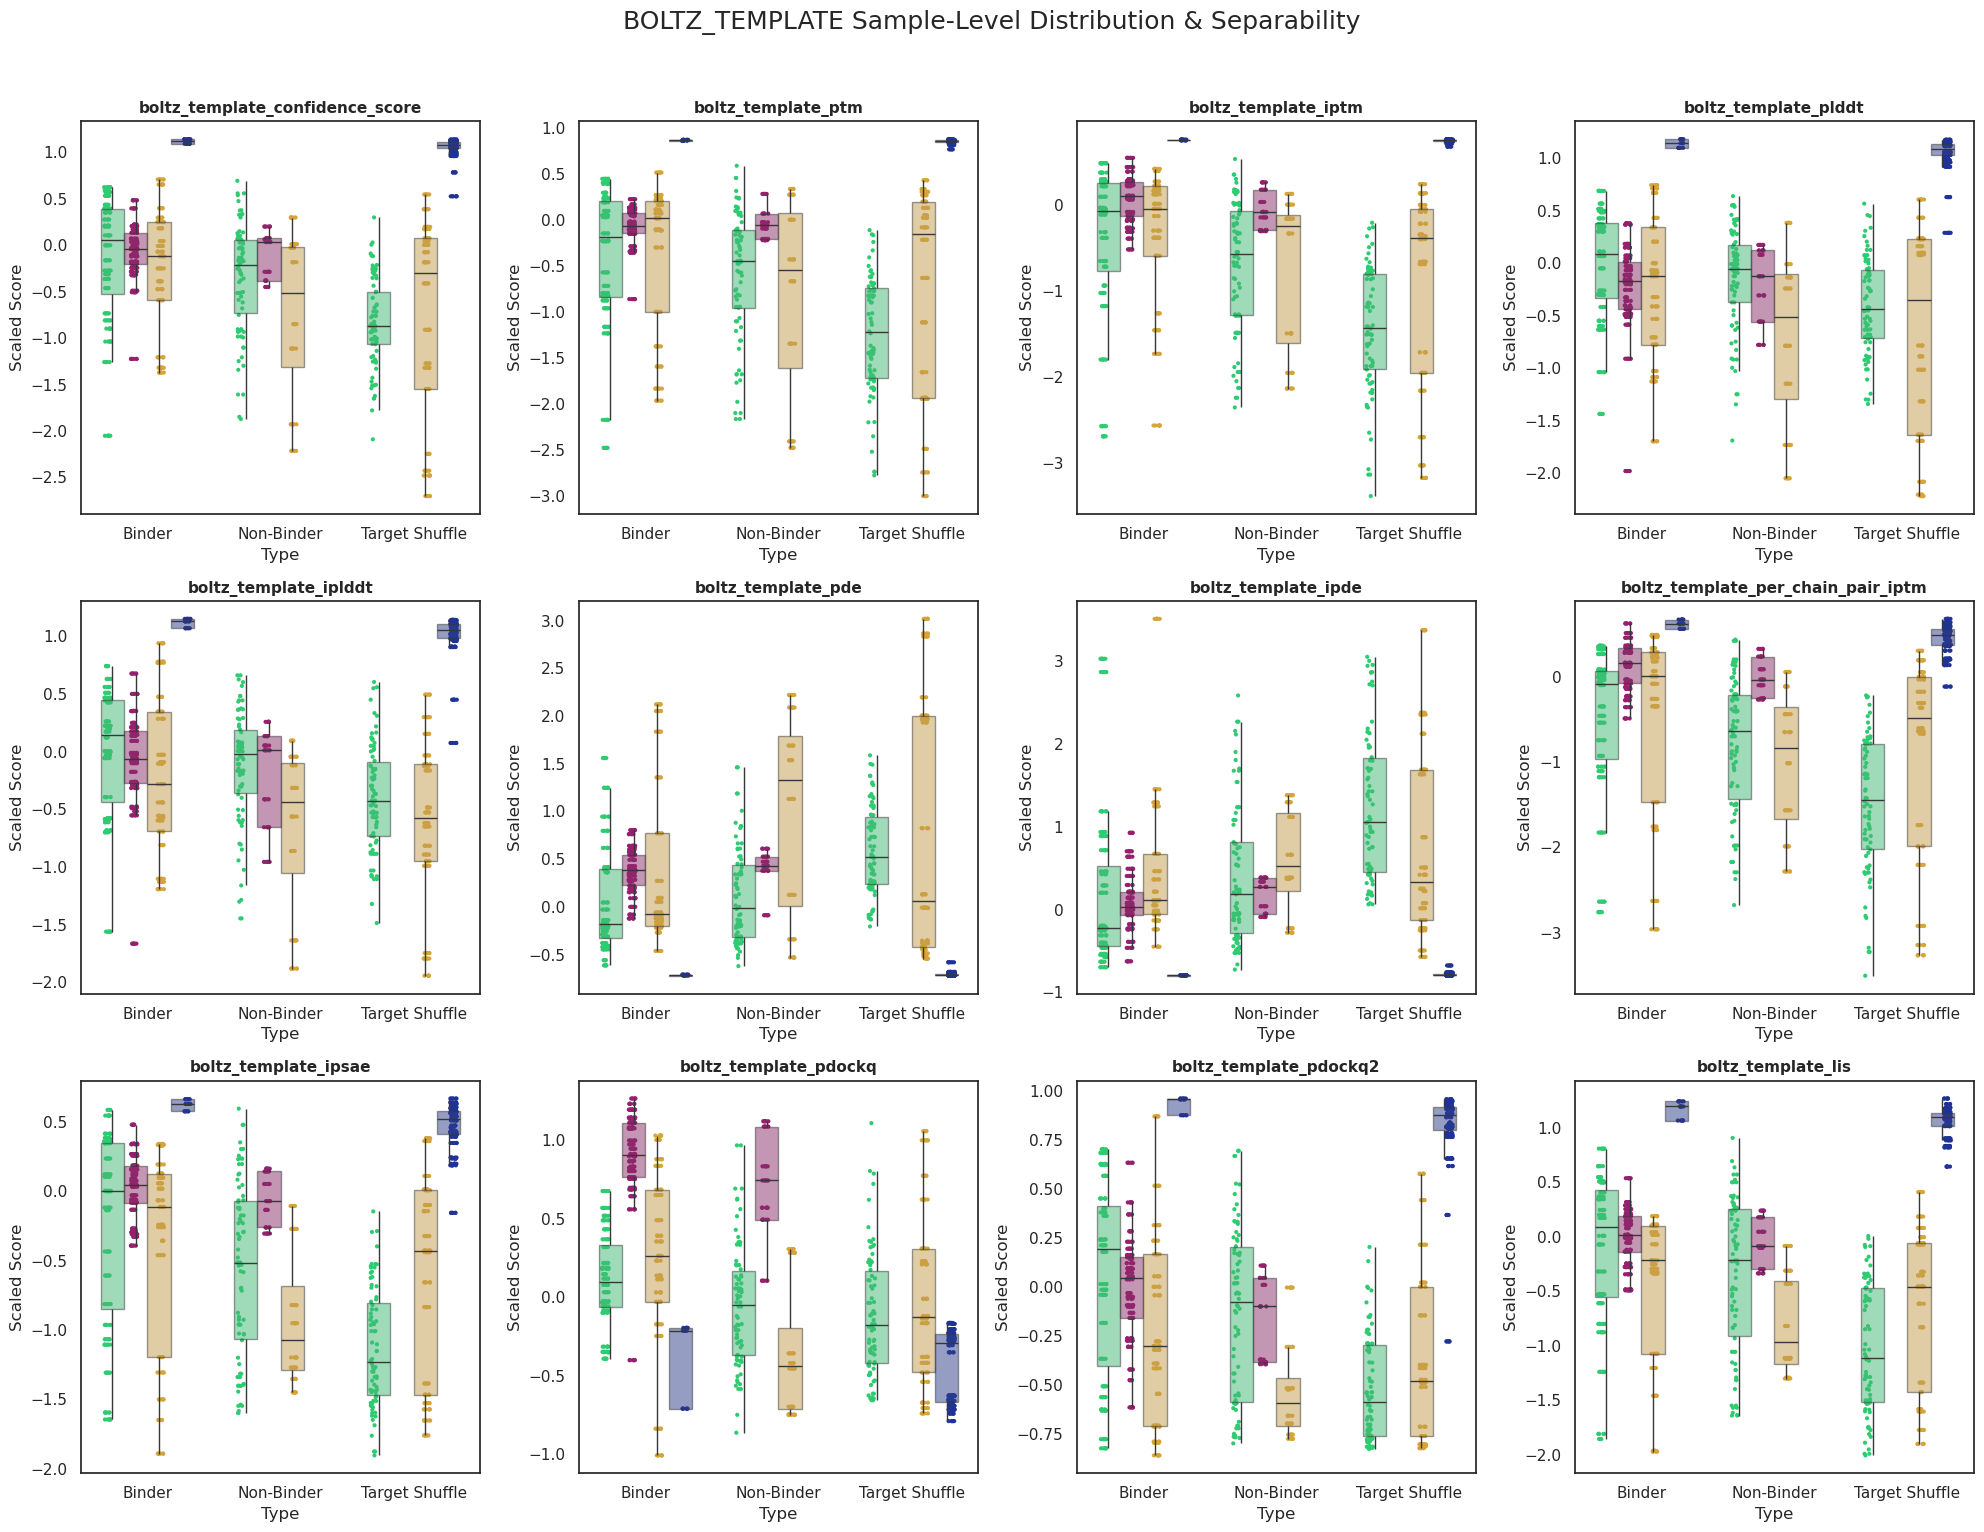

Finished generating scatterplots.


In [17]:
# Detailed Separability
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='white')

x_order = ['Binder', 'Non-Binder', 'Target Shuffle']

for model, cols in model_groups.items():
    if not cols:
        continue

    # ── FIX 6: filter long_scores_df by metric column, use y='value' ──
    model_long = long_scores_df[long_scores_df['metric'].isin(cols)]
    valid_metrics = [c for c in cols if not model_long[model_long['metric'] == c]['value'].isna().all()]
    if not valid_metrics:
        print(f"Skipping {model.upper()}: No valid numeric data.")
        continue

    n_cols_grid = 4
    n_rows = (len(valid_metrics) + n_cols_grid - 1) // n_cols_grid
    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(20, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for i, metric in enumerate(valid_metrics):
        ax = axes[i]
        plot_df = model_long[model_long['metric'] == metric].dropna(subset=['value']).copy()
        if plot_df.empty:
            continue

        hue_order = sorted(plot_df['source'].unique())

        sns.stripplot(
            data=plot_df, x='binder_type', y='value', order=x_order,
            hue='source', hue_order=hue_order, dodge=True, jitter=0.1,
            palette=colors_map, size=3, ax=ax, legend=False
        )
        sns.boxplot(
            data=plot_df, x='binder_type', y='value', order=x_order,
            dodge=True, showcaps=False, fill=True,
            hue='source', hue_order=hue_order,
            palette=colors_map, ax=ax, width=0.7, zorder=10,
            showfliers=False, legend=False
        )
        for artist in ax.patches:
            artist.set_alpha(0.5)

        ax.set_title(metric, fontsize=11, fontweight='bold')
        ax.set_xlabel('Type')
        ax.set_ylabel('Scaled Score')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'{model.upper()} Sample-Level Distribution & Separability', fontsize=18, y=1.02)
    plt.tight_layout()

    save_path = OUTPUT_DIR / f'{model}_separability_scatter.png'
    plt.savefig(save_path, dpi=200, bbox_inches='tight')  # save BEFORE show
    plt.show()

print(f'Finished generating scatterplots.')


#### Correlation Matrix

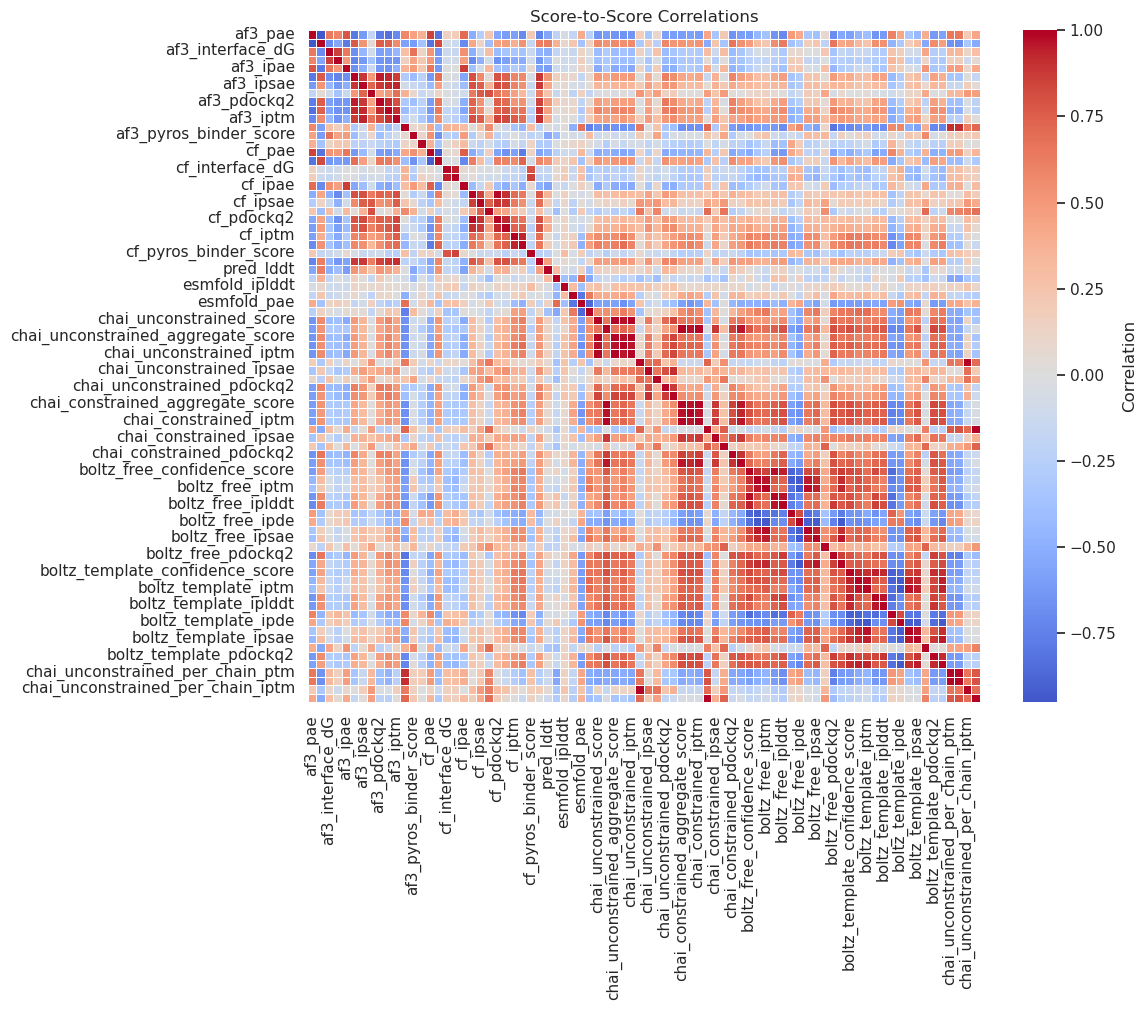

In [18]:
# Correlation matrix (on scaled data, metrics only)
numeric_df = scores_df_scaled[numeric_cols].dropna(axis=1, how='all')

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix, annot=False, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'}
)
plt.title('Score-to-Score Correlations')
plt.tight_layout()

# ── FIX 7: save BEFORE show (show() clears the figure) ──
plt.savefig(OUTPUT_DIR / 'score_correlation_heatmap.png', dpi=500, bbox_inches='tight')
plt.show()
